# 03a — Deterministic Individual Simulation

Calculate deterministic lifetime retirement values under High-Three
and BRS for each profile and separation scenario.

**TSP modeling:** Member contributes 5% under both systems.
BRS adds government contributions: 1% automatic from entry, plus
up to 4% matching beginning after 2 years of service, so the BRS
total is 6% in YOS 1–2 and 10% from YOS 3. High-Three total stays
at 5%. The comparison isolates what the government provides
differently.

**Dollar convention:** basic pay grows at the COLA rate (military
raises are assumed to track inflation), making the model internally
consistent in nominal terms; all reported values are then deflated
by the price level at separation and expressed in **constant 2026
dollars**.

**Fixed assumptions:** pay growth = COLA = 2.75% (DoD actuarial);
TSP returns = glide-path L Fund historical means; life expectancy =
SSA 2022 male expected total age.

**Inputs:** `data/processed/pay_profiles.csv`,
`data/processed/tsp_returns.csv`,
`data/processed/life_expectancy.csv`
**Output:** `data/processed/deterministic_results.csv`


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path("../src")))
from pension_calcs import (  # noqa: E402
    annual_pension_brs,
    annual_pension_high3,
    high_three_base,
)
from tsp_calcs import (  # noqa: E402
    BRS_CONTRIB_RATE,
    brs_total_rate,
    H3_MEMBER_RATE,
    compute_fund_means,
    tsp_at_separation,
    tsp_grow_to_60,
)
from utils import npv_pension, pv_lump_sum  # noqa: E402

PROCESSED = Path("../data/processed")

## Model constants

In [2]:
PROFILES = ["Officer", "Enlisted", "PriorEnlistedOfficer"]
PROFILE_SCENARIOS = {
    "Officer": list(range(4, 41, 2)),
    "Enlisted": list(range(4, 31, 2)),
    "PriorEnlistedOfficer": list(range(4, 41, 2)),
}
ENTRY_AGE = {
    "Officer": 22,
    "Enlisted": 18,
    "PriorEnlistedOfficer": 18,
}

COLA_RATE = 0.0275      # DoD Board of Actuaries long-term
PAY_GROWTH = COLA_RATE  # basic pay raises assumed to track COLA
DISCOUNT_RATE = 0.05    # Nominal rate for NPV calculations

print(
    f"BRS contribution: {BRS_CONTRIB_RATE:.0%} total from YOS 3"
    " (member 5% + govt 1% auto + 4% match);"
)
print(
    "                  6% in YOS 1-2"
    " (match starts after 2 years)"
)
print(
    f"H3  contribution: {H3_MEMBER_RATE:.0%}"
    " (member 5% only)"
)
print("Reporting units:  constant 2026 dollars")


BRS contribution: 10% total from YOS 3 (member 5% + govt 1% auto + 4% match);
                  6% in YOS 1-2 (match starts after 2 years)
H3  contribution: 5% (member 5% only)
Reporting units:  constant 2026 dollars


## Load data

In [3]:
pay_profiles = pd.read_csv(PROCESSED / "pay_profiles.csv")
tsp_returns = pd.read_csv(PROCESSED / "tsp_returns.csv")
life_exp = pd.read_csv(PROCESSED / "life_expectancy.csv")

print(f"pay_profiles: {pay_profiles.shape}")
print(f"tsp_returns:  {tsp_returns.shape}")
print(f"life_exp:     {life_exp.shape}")

pay_profiles: (110, 3)
tsp_returns:  (39, 21)
life_exp:     (120, 5)


## TSP glide-path fund means

Historical mean annual return for each L Fund used in the glide path.
These are the fixed returns for the deterministic scenario; notebook
03b will draw from the full return distributions.

**Data note:** L Fund return histories are extended back to 2002 via
synthetic reconstruction — regression weights (SLSQP, constrained to
sum to 1) fit on the overlapping period are applied to the five
underlying individual-fund returns (C, S, I, F, G). Only pre-inception
NaN values are backfilled; actual reported values are unchanged.
R² > 0.99 for all four L Funds. L 2050 gains 10 additional years
(n: 14 → 24), correcting for selection bias from its 2012 inception
missing the 2001–2002 bear market.

In [4]:
means = compute_fund_means(tsp_returns)

print("L Fund mean annual returns (deterministic baseline):")
for fund, r in means.items():
    n = tsp_returns[fund].notna().sum()
    print(f"  {fund:<12} {r:.2%}  (n={n} years)")

L Fund mean annual returns (deterministic baseline):
  L 2050       9.47%  (n=24 years)
  L 2040       8.93%  (n=24 years)
  L 2030       8.09%  (n=24 years)
  L Income     4.80%  (n=24 years)


## Officer, 20 YOS — step-by-step walkthrough

Both systems credit the member's own 5% TSP contribution.
The difference between systems comes only from the govt's 5%
addition (BRS only) and the pension multiplier difference.

In [5]:
DEMO_PROFILE = "Officer"
DEMO_YOS = 20
sep_age = ENTRY_AGE[DEMO_PROFILE] + DEMO_YOS

pay = pay_profiles.query(
    "Profile == @DEMO_PROFILE and YOS <= @DEMO_YOS"
).set_index("YOS")["MonthlyPay"]

# Nominal pay: 2026 table grown at PAY_GROWTH per year
pay_nom = pay * (1 + PAY_GROWTH) ** (
    pay.index.to_numpy() - 1
)
# Deflator: price level at separation vs. 2026
DEFL = (1 + COLA_RATE) ** DEMO_YOS

h3_base = high_three_base(pay_nom)

life_row = life_exp.loc[
    life_exp["Age"] == sep_age
].squeeze()
n_pension_yrs = life_row["MaleTotalAge"] - sep_age

print(f"Profile: {DEMO_PROFILE}, Sep YOS: {DEMO_YOS}")
print(f"Separation age:     {sep_age}")
print(
    f"High-Three base:    ${h3_base:>10,.2f}/month nominal"
    f"  (${h3_base / DEFL:,.2f} in 2026 $)"
)
print(
    f"Life expectancy:    {life_row['MaleTotalAge']:.1f}"
    f"  ({n_pension_yrs:.1f} pension years)"
)
print(f"Deflator to 2026 $: {DEFL:.3f}")


Profile: Officer, Sep YOS: 20
Separation age:     42
High-Three base:    $ 19,271.12/month nominal  ($11,201.35 in 2026 $)
Life expectancy:    77.9  (35.9 pension years)
Deflator to 2026 $: 1.720


In [6]:
tsp_sep_brs = tsp_at_separation(
    pay_nom, ENTRY_AGE[DEMO_PROFILE], means, brs_total_rate
)
tsp_sep_h3 = tsp_at_separation(
    pay_nom, ENTRY_AGE[DEMO_PROFILE], means, H3_MEMBER_RATE
)
gap_yrs = 60 - sep_age
tsp_60_brs = tsp_grow_to_60(tsp_sep_brs, sep_age, means)
tsp_60_h3 = tsp_grow_to_60(tsp_sep_h3, sep_age, means)
tsp_pv_brs = pv_lump_sum(
    tsp_60_brs, gap_yrs, DISCOUNT_RATE
) / DEFL
tsp_pv_h3 = pv_lump_sum(
    tsp_60_h3, gap_yrs, DISCOUNT_RATE
) / DEFL

print("TSP at separation (nominal):")
print(f"  BRS:             ${tsp_sep_brs:>12,.0f}")
print(f"  H3:              ${tsp_sep_h3:>12,.0f}")
print("TSP at age 60 (nominal):")
print(f"  BRS:             ${tsp_60_brs:>12,.0f}")
print(f"  H3:              ${tsp_60_h3:>12,.0f}")
print(
    f"TSP PV at separation, 2026 $"
    f" ({gap_yrs} yr @ {DISCOUNT_RATE:.0%}):"
)
print(f"  BRS:             ${tsp_pv_brs:>12,.0f}")
print(f"  H3:              ${tsp_pv_h3:>12,.0f}")
print(
    f"  Govt portion:    "
    f"${tsp_pv_brs - tsp_pv_h3:>12,.0f}  (BRS-only)"
)


TSP at separation (nominal):
  BRS:             $     644,298
  H3:              $     334,907
TSP at age 60 (nominal):
  BRS:             $   1,978,496
  H3:              $   1,028,425
TSP PV at separation, 2026 $ (18 yr @ 5%):
  BRS:             $     477,849
  H3:              $     248,387
  Govt portion:    $     229,463  (BRS-only)


In [7]:
h3_annual = annual_pension_high3(h3_base, DEMO_YOS)
brs_annual = annual_pension_brs(h3_base, DEMO_YOS)

h3_npv = npv_pension(
    h3_annual, COLA_RATE, DISCOUNT_RATE, n_pension_yrs
) / DEFL
brs_npv = npv_pension(
    brs_annual, COLA_RATE, DISCOUNT_RATE, n_pension_yrs
) / DEFL

h3_total = h3_npv + tsp_pv_h3
brs_total = brs_npv + tsp_pv_brs
diff = brs_total - h3_total

W = 14
print(
    "Lifetime retirement value"
    " (NPV at separation, constant 2026 $):"
)
print(f"  {'':30} {'High-Three':>{W}} {'BRS':>{W}}")
print("  " + "-" * (32 + W * 2))
print(
    f"  {'Annual pension (nominal)':30}"
    f" ${h3_annual:{W-1},.0f} ${brs_annual:{W-1},.0f}"
)
print(
    f"  {'Pension NPV':30}"
    f" ${h3_npv:{W-1},.0f} ${brs_npv:{W-1},.0f}"
)
print(
    f"  {'Member TSP PV (5%)':30}"
    f" ${tsp_pv_h3:{W-1},.0f} ${tsp_pv_h3:{W-1},.0f}"
)
print(
    f"  {'Govt TSP PV (BRS only)':30}"
    f" {'—':>{W}} ${(tsp_pv_brs - tsp_pv_h3):{W-1},.0f}"
)
print("  " + "-" * (32 + W * 2))
print(
    f"  {'Total NPV':30}"
    f" ${h3_total:{W-1},.0f} ${brs_total:{W-1},.0f}"
)
sign = "+" if diff >= 0 else ""
print(f"\n  Difference (BRS - H3): {sign}${diff:,.0f}")


Lifetime retirement value (NPV at separation, constant 2026 $):
                                     High-Three            BRS
  ------------------------------------------------------------
  Annual pension (nominal)       $      115,627 $       92,501
  Pension NPV                    $    1,696,172 $    1,356,938
  Member TSP PV (5%)             $      248,387 $      248,387
  Govt TSP PV (BRS only)                      — $      229,463
  ------------------------------------------------------------
  Total NPV                      $    1,944,559 $    1,834,787

  Difference (BRS - H3): $-109,772


## All profiles and scenarios

In [8]:
profile_max = (
    pay_profiles.groupby("Profile")["YOS"].max()
)


def calc_lifetime(profile, sep_yos):
    """Deterministic lifetime values, constant 2026 $."""
    if sep_yos > profile_max[profile]:
        return None
    sep_age = ENTRY_AGE[profile] + sep_yos
    pay = pay_profiles.query(
        "Profile == @profile and YOS <= @sep_yos"
    ).set_index("YOS")["MonthlyPay"]
    pay_nom = pay * (1 + PAY_GROWTH) ** (
        pay.index.to_numpy() - 1
    )
    defl = (1 + COLA_RATE) ** sep_yos

    h3_base = high_three_base(pay_nom)
    life_row = life_exp.loc[
        life_exp["Age"] == sep_age
    ].squeeze()
    n_pens = life_row["MaleTotalAge"] - sep_age

    gap = max(0, 60 - sep_age)
    tsp_pv_brs = pv_lump_sum(
        tsp_grow_to_60(
            tsp_at_separation(
                pay_nom, ENTRY_AGE[profile], means,
                brs_total_rate,
            ),
            sep_age, means,
        ),
        gap, DISCOUNT_RATE,
    ) / defl
    tsp_pv_h3 = pv_lump_sum(
        tsp_grow_to_60(
            tsp_at_separation(
                pay_nom, ENTRY_AGE[profile], means,
                H3_MEMBER_RATE,
            ),
            sep_age, means,
        ),
        gap, DISCOUNT_RATE,
    ) / defl

    if sep_yos >= 20:
        h3_ann = annual_pension_high3(h3_base, sep_yos)
        brs_ann = annual_pension_brs(h3_base, sep_yos)
        h3_npv = npv_pension(
            h3_ann, COLA_RATE, DISCOUNT_RATE, n_pens
        ) / defl
        brs_npv = npv_pension(
            brs_ann, COLA_RATE, DISCOUNT_RATE, n_pens
        ) / defl
    else:
        h3_ann = brs_ann = h3_npv = brs_npv = 0.0

    h3_total = h3_npv + tsp_pv_h3
    brs_total = brs_npv + tsp_pv_brs
    return {
        "Profile": profile,
        "SepYOS": sep_yos,
        "SepAge": sep_age,
        "H3Annual": h3_ann,
        "H3PensionNPV": h3_npv,
        "H3TSP_PV": tsp_pv_h3,
        "H3Total": h3_total,
        "BRSAnnual": brs_ann,
        "BRSPensionNPV": brs_npv,
        "BRS_TSP_PV": tsp_pv_brs,
        "BRSTotal": brs_total,
        "BRSAdv": brs_total - h3_total,
    }


In [9]:
rows = []
for profile in PROFILES:
    for sep_yos in PROFILE_SCENARIOS[profile]:
        row = calc_lifetime(profile, sep_yos)
        if row is not None:
            rows.append(row)

results = pd.DataFrame(rows)
print(f"{len(results)} scenarios computed.")
results.head(10)

52 scenarios computed.

,Profile,SepYOS,SepAge,H3Annual,H3PensionNPV,H3TSP_PV,H3Total,BRSAnnual,BRSPensionNPV,BRS_TSP_PV,BRSTotal,BRSAdv
0,Officer,4,26,0.000000,0.000000e+00,37732.235206,3.773224e+04,0.000000,0.000000e+00,62083.213576,6.208321e+04,24350.978370
1,Officer,6,28,0.000000,0.000000e+00,60841.524975,6.084152e+04,0.000000,0.000000e+00,107709.336168,1.077093e+05,46867.811193
2,Officer,8,30,0.000000,0.000000e+00,84228.547978,8.422855e+04,0.000000,0.000000e+00,153864.694116,1.538647e+05,69636.146138
3,Officer,10,32,0.000000,0.000000e+00,108983.994677,1.089840e+05,0.000000,0.000000e+00,202729.506959,2.027295e+05,93745.512283
4,Officer,12,34,0.000000,0.000000e+00,135288.583710,1.352886e+05,0.000000,0.000000e+00,254663.999168,2.546640e+05,119375.415458
5,Officer,14,36,0.000000,0.000000e+00,162061.167108,1.620612e+05,0.000000,0.000000e+00,307504.608299,3.075046e+05,145443.441191
6,Officer,16,38,0.000000,0.000000e+00,189966.392148,1.899664e+05,0.000000,0.000000e+00,362579.306328,3.625793e+05,172612.914180
7,Officer,18,40,0.000000,0.000000e+00,218998.698077,2.189987e+05,0.000000,0.000000e+00,419875.590615,4.198756e+05,200876.892538
8,Officer,20,42,115626.743678,1.696172e+06,248386.799793,1.944559e+06,92501.394942,1.356938e+06,477849.448669,1.834787e+06,-109771.727653
9,Officer,22,44,144752.711792,1.945657e+06,279729.835261,2.225387e+06,115802.169433,1.556526e+06,539697.650277,2.096223e+06,-129163.607507


## Results summary

Total NPV by system, profile, and separation YOS.
Values in constant 2026 \$ thousands. `H3Annual` / `BRSAnnual` are nominal at separation. Both systems credit the member's own 5%
TSP contribution; the difference reflects only government-funded
components (govt TSP contribution + pension multiplier).

In [10]:
def pivot_k(col):
    """Pivot results column to profile x YOS, 2026 $K."""
    return results.pivot(
        index="Profile", columns="SepYOS", values=col
    ).round(0) / 1000


print("High-Three total NPV (2026 $ thousands):")
print(pivot_k("H3Total").to_string())
print()
print("BRS total NPV (2026 $ thousands):")
print(pivot_k("BRSTotal").to_string())
print()
print("Difference, BRS - H3 (2026 $ thousands)  [+ = BRS higher]:")
print(pivot_k("BRSAdv").to_string())

High-Three total NPV (2026 $ thousands):
SepYOS                    4       6       8        10       12       14       16       18        20        22        24        26        28        30        32        34        36        38        40
Profile                                                                                                                                                                                                
Enlisted              24.258  38.330  52.989   68.627   84.452  101.907  119.590  138.588  1205.303  1458.076  1671.690  1836.356  1986.513  2096.604       NaN       NaN       NaN       NaN       NaN
Officer               37.732  60.842  84.229  108.984  135.289  162.061  189.966  218.999  1944.559  2225.387  2601.800  2816.412  3120.258  3452.644  3808.089  3997.930  4064.154  4112.210  4137.863
PriorEnlistedOfficer  24.258  38.330  52.989   72.073   95.287  120.870  146.269  172.883  1801.952  1939.004  2177.923  2524.422  2643.571  2950.540  3442.620

## Lifetime value comparison by career length

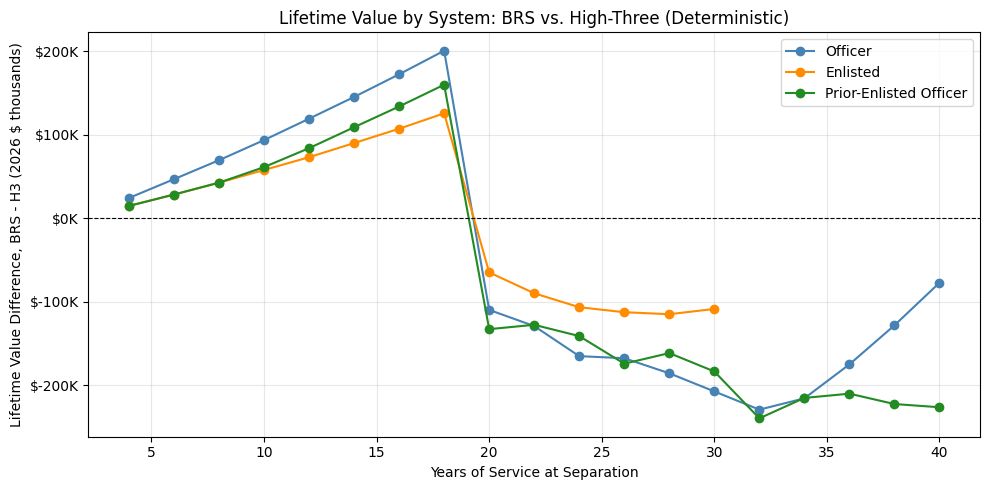

Key assumptions (deterministic baseline):
  Pay growth:         2.75%  (raises assumed to track COLA)
  COLA rate:          2.75%  (DoD Board of Actuaries long-term)
  Discount rate:      5.00%  (nominal NPV)
  TSP, BRS total:     10.00%  (YOS 3+; 6% in YOS 1-2)
  TSP, H3 total:      5.00%  (member 5% only)
  TSP returns:        glide-path L Fund historical means
  Life expectancy:    SSA 2022, male expected total age
  Reporting units:    constant 2026 dollars


In [11]:
profile_styles = {
    "Officer": ("steelblue", "Officer"),
    "Enlisted": ("darkorange", "Enlisted"),
    "PriorEnlistedOfficer": (
        "forestgreen", "Prior-Enlisted Officer"
    ),
}

fig, ax = plt.subplots(figsize=(10, 5))

for profile, (color, label) in profile_styles.items():
    sub = results[results["Profile"] == profile]
    ax.plot(
        sub["SepYOS"],
        sub["BRSAdv"] / 1000,
        marker="o",
        label=label,
        color=color,
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Years of Service at Separation")
ax.set_ylabel(
    "Lifetime Value Difference, BRS - H3 (2026 $ thousands)"
)
ax.set_title(
    "Lifetime Value by System: BRS vs. High-Three"
    " (Deterministic)"
)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}K")
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Key assumptions (deterministic baseline):")
print(
    f"  Pay growth:         {PAY_GROWTH:.2%}"
    "  (raises assumed to track COLA)"
)
print(
    f"  COLA rate:          {COLA_RATE:.2%}"
    "  (DoD Board of Actuaries long-term)"
)
print(
    f"  Discount rate:      {DISCOUNT_RATE:.2%}"
    "  (nominal NPV)"
)
print(
    f"  TSP, BRS total:     {BRS_CONTRIB_RATE:.2%}"
    "  (YOS 3+; 6% in YOS 1-2)"
)
print(
    f"  TSP, H3 total:      {H3_MEMBER_RATE:.2%}"
    "  (member 5% only)"
)
print(
    "  TSP returns:        glide-path L Fund"
    " historical means"
)
print(
    "  Life expectancy:    SSA 2022, male"
    " expected total age"
)
print("  Reporting units:    constant 2026 dollars")

## Save

In [12]:
out = PROCESSED / "deterministic_results.csv"
results.to_csv(out, index=False)
print(f"Saved: {out.name}  ({out.stat().st_size/1024:.1f} KB)")

Saved: deterministic_results.csv  (8.2 KB)
